# Module 7: Classification, Model Optimization and Evaluation
## Wisconsin Diagnostic Breast Cancer (WDBC) Dataset

**Dataset:** UCI WDBC — 569 samples, 30 numeric features, binary target (Malignant / Benign)  
**Goal:** Build, evaluate, and improve a binary classifier to predict breast cancer diagnosis.


## 0. Imports & Setup

In [29]:
!pip install shap statsmodels

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Load the Dataset

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Column names from wdbc.names
feature_names = [
    'radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean',
    'compactness_mean','concavity_mean','concave_points_mean','symmetry_mean','fractal_dimension_mean',
    'radius_se','texture_se','perimeter_se','area_se','smoothness_se',
    'compactness_se','concavity_se','concave_points_se','symmetry_se','fractal_dimension_se',
    'radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst',
    'compactness_worst','concavity_worst','concave_points_worst','symmetry_worst','fractal_dimension_worst'
]
col_names = ['id', 'diagnosis'] + feature_names

df = pd.read_csv('/content/drive/MyDrive/Datasets/wdbc.data', header=None, names=col_names)
df.drop(columns=['id'], inplace=True)

# Encode target: M=1 (Malignant), B=0 (Benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print(f"Shape: {df.shape}")
df.head()


Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Data Quality Check

In [9]:
print("=== Missing Values ===")
print(df.isnull().sum().sum(), "total missing values\n")

print("=== Data Types ===")
print(df.dtypes.value_counts(), "\n")

print("=== Class Distribution ===")
counts = df['diagnosis'].value_counts()
print(f"Benign  (0): {counts[0]}  ({counts[0]/len(df)*100:.1f}%)")
print(f"Malignant (1): {counts[1]}  ({counts[1]/len(df)*100:.1f}%)")

print("\n=== Descriptive Statistics (first 5 features) ===")
df[feature_names[:5]].describe().round(3)


=== Missing Values ===
0 total missing values

=== Data Types ===
float64    30
int64       1
Name: count, dtype: int64 

=== Class Distribution ===
Benign  (0): 357  (62.7%)
Malignant (1): 212  (37.3%)

=== Descriptive Statistics (first 5 features) ===


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean
count,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096
std,3.524,4.301,24.299,351.914,0.014
min,6.981,9.710,43.790,143.500,0.053
25%,11.700,16.170,75.170,420.300,0.086
50%,13.370,18.840,86.240,551.100,0.096
75%,15.780,21.800,104.100,782.700,0.105
max,28.110,39.280,188.500,2501.000,0.163


## 3. Exploratory Data Analysis (EDA)

### Plot 1 — Class Distribution

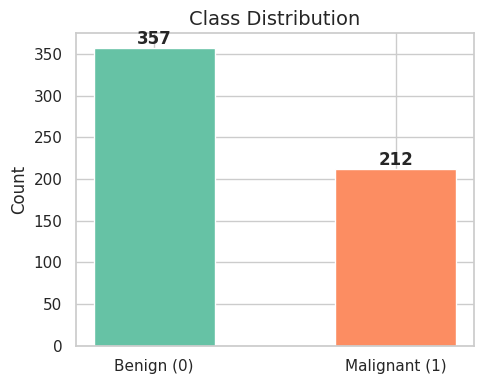

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['diagnosis'].value_counts()
bars = ax.bar(['Benign (0)', 'Malignant (1)'], counts.values,
               color=['#66c2a5', '#fc8d62'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution', fontsize=14)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=90)
plt.show()
plt.close()


**Rationale:** A bar chart is the clearest way to visualise discrete class counts and immediately surface any class imbalance before modelling.

**Interpretation:** The dataset contains 357 Benign and 212 Malignant samples (~63/37 split). This mild imbalance is worth noting: the majority class (Benign) could bias a naive classifier. However, at 63/37 the skew is not severe enough to require resampling. On more imbalanced datasets, techniques such as **SMOTE** (Synthetic Minority Over-sampling Technique) or **class weighting** (`class_weight='balanced'` in scikit-learn) would be appropriate to prevent the model from simply predicting the majority class.


### Plot 2 — Feature Distributions by Diagnosis (Mean Features)

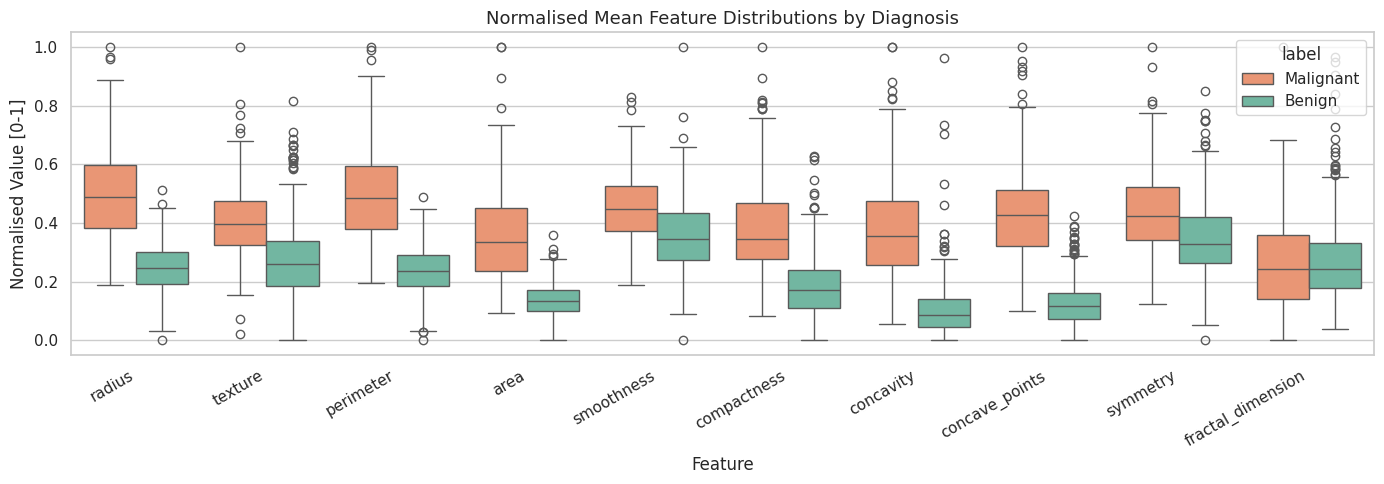

In [11]:
mean_features = [c for c in feature_names if c.endswith('_mean')]
df_melt = df[mean_features + ['diagnosis']].melt(id_vars='diagnosis',
                                                   var_name='feature',
                                                   value_name='value')
df_melt['feature'] = df_melt['feature'].str.replace('_mean', '', regex=False)
df_melt['label'] = df_melt['diagnosis'].map({0: 'Benign', 1: 'Malignant'})

# Normalise each feature for fair visual comparison
from sklearn.preprocessing import MinMaxScaler
scaler_vis = MinMaxScaler()
df_scaled_vis = df[mean_features].copy()
df_scaled_vis = pd.DataFrame(scaler_vis.fit_transform(df_scaled_vis), columns=mean_features)
df_scaled_vis['diagnosis'] = df['diagnosis'].values
df_m2 = df_scaled_vis.melt(id_vars='diagnosis', var_name='feature', value_name='value')
df_m2['feature'] = df_m2['feature'].str.replace('_mean', '', regex=False)
df_m2['label'] = df_m2['diagnosis'].map({0: 'Benign', 1: 'Malignant'})

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df_m2, x='feature', y='value', hue='label',
            palette={'Benign': '#66c2a5', 'Malignant': '#fc8d62'}, ax=ax)
ax.set_title('Normalised Mean Feature Distributions by Diagnosis', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Normalised Value [0-1]')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plot2_boxplot.png', dpi=90)
plt.show()
plt.close()


**Rationale:** Side-by-side box plots show how each feature separates the two classes and reveal the median, spread, and outliers simultaneously — far more informative than a raw correlation number.  
**Interpretation:** Features such as *radius*, *perimeter*, *area*, and *concavity* show the clearest separation between Benign and Malignant tumours, with malignant samples consistently higher. *Fractal dimension* and *symmetry* show the least separation, suggesting they may contribute less predictive signal.


### Plot 3 — Correlation Heatmap (Mean Features)

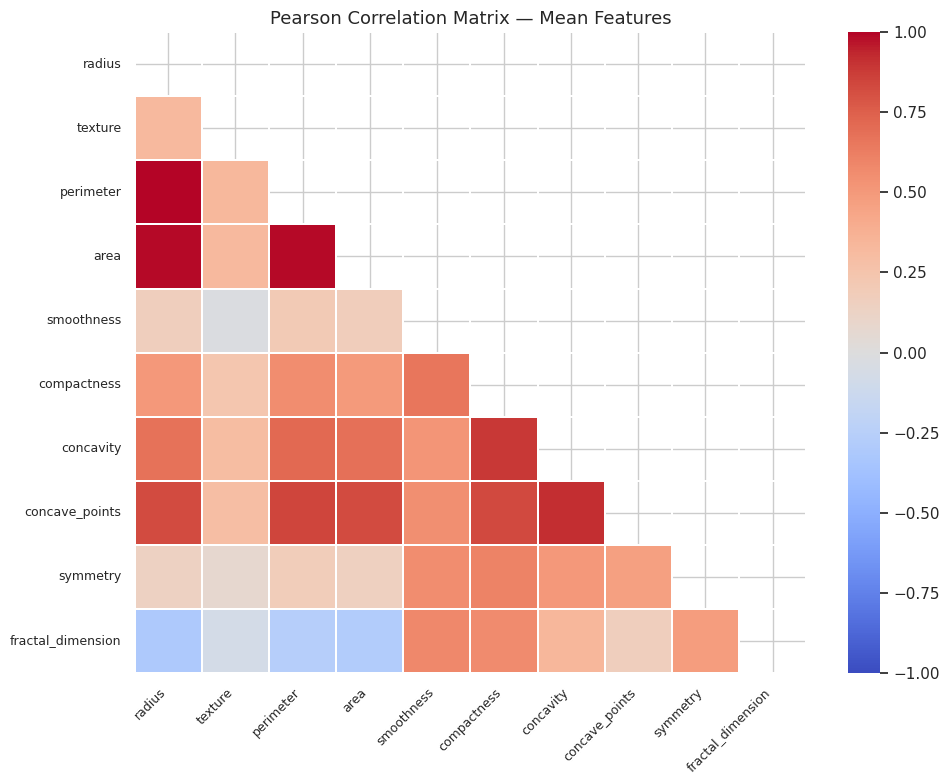

In [12]:
corr = df[mean_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax, vmin=-1, vmax=1)
short = [f.replace('_mean', '') for f in mean_features]
ax.set_xticklabels(short, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short, rotation=0, fontsize=9)
ax.set_title('Pearson Correlation Matrix — Mean Features', fontsize=13)
plt.tight_layout()
plt.savefig('plot3_correlation.png', dpi=90)
plt.show()
plt.close()


**Rationale:** A correlation heatmap reveals multicollinearity among features. Highly correlated features carry redundant information and can destabilise some models or complicate interpretation.  
**Interpretation:** *Radius*, *perimeter*, and *area* are almost perfectly correlated (r > 0.99), which is expected geometrically. *Concavity* and *concave points* are also strongly correlated. This redundancy motivates feature selection in the improvement phase — keeping all three size-related features adds noise without adding information.


### Plot 4 — Pairplot of Top Separating Features

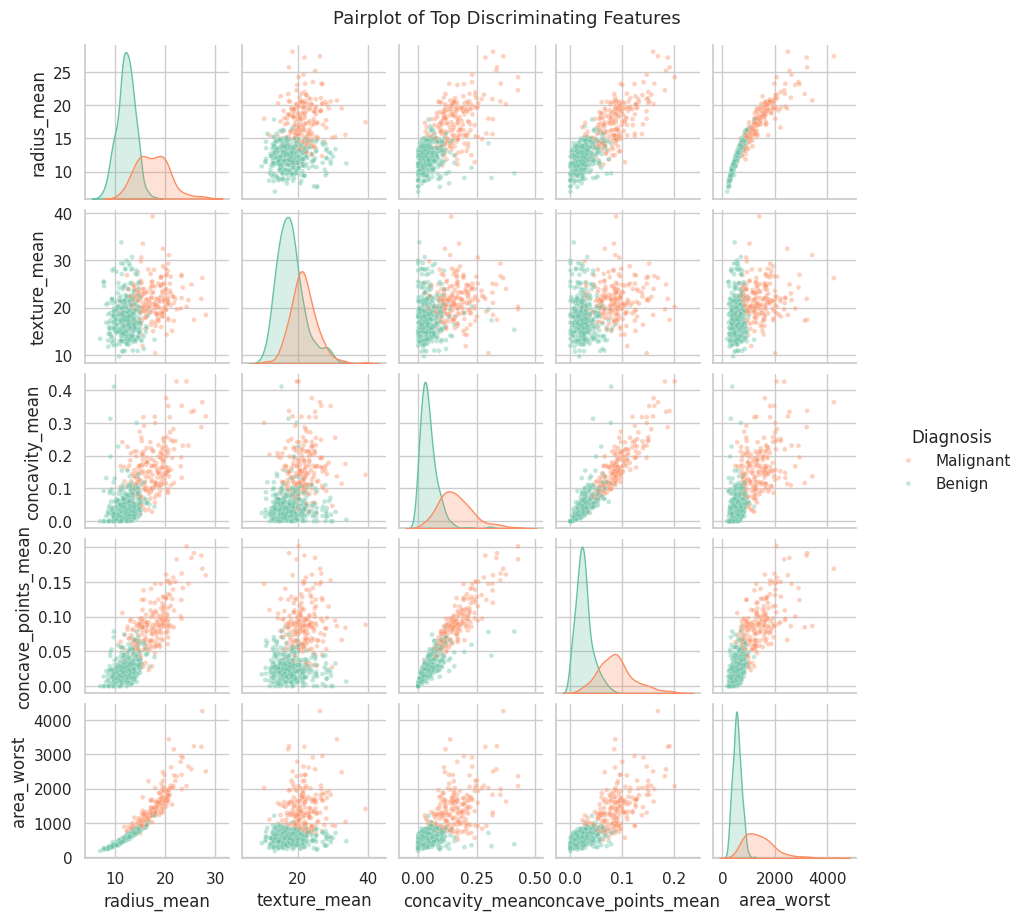

In [13]:
top_feats = ['radius_mean', 'texture_mean', 'concavity_mean',
             'concave_points_mean', 'area_worst']
plot_df = df[top_feats + ['diagnosis']].copy()
plot_df['Diagnosis'] = plot_df['diagnosis'].map({0: 'Benign', 1: 'Malignant'})

g = sns.pairplot(plot_df.drop(columns='diagnosis'),
                 height=1.8, aspect=1,
                 hue='Diagnosis',
                 palette={'Benign': '#66c2a5', 'Malignant': '#fc8d62'},
                 plot_kws={'alpha': 0.4, 's': 12},
                 diag_kind='kde')
g.fig.suptitle('Pairplot of Top Discriminating Features', y=1.02, fontsize=13)
plt.savefig('plot4_pairplot.png', dpi=70)
plt.show()
plt.close()


**Rationale:** A pairplot of the most discriminating features shows pairwise class separation and the shape of each marginal distribution — ideal for confirming which feature combinations form the clearest boundaries.  
**Interpretation:** The off-diagonal scatter plots reveal near-linear separability between Benign and Malignant classes for combinations like *radius_mean* vs *concave_points_mean* and *area_worst* vs *concavity_mean*. The KDE diagonals confirm bimodal distributions for most features, reinforcing that these features carry strong discriminative power.


## 4. Train / Test Split

In [14]:
X = df[feature_names].values
y = df['diagnosis'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Class balance (train) — Benign: {(y_train==0).sum()}  Malignant: {(y_train==1).sum()}")
print(f"Class balance (test)  — Benign: {(y_test==0).sum()}   Malignant: {(y_test==1).sum()}")

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


Training set : 455 samples
Test set     : 114 samples
Class balance (train) — Benign: 285  Malignant: 170
Class balance (test)  — Benign: 72   Malignant: 42


**Split choice:** An 80/20 train-test split was chosen to give the model sufficient data to learn patterns while reserving a representative held-out set for unbiased evaluation. `stratify=y` ensures both splits reflect the original class ratio. `StandardScaler` is fit exclusively on the training set and applied to the test set to prevent data leakage.

**Cross-validation folds:** `cv=5` (5-fold cross-validation) was used throughout hyperparameter tuning. This is a well-established default that balances bias-variance trade-off: with ~455 training samples, 5 folds give ~364 samples for training and ~91 for validation per fold — large enough for stable estimates without excessive computation. On smaller datasets `cv=10` might be preferred; on very large datasets `cv=3` is often sufficient.


## 5. Baseline Model — Logistic Regression

In [15]:
baseline = LogisticRegression(max_iter=10000, random_state=42)
baseline.fit(X_train_s, y_train)
y_pred_base = baseline.predict(X_test_s)

acc  = accuracy_score(y_test, y_pred_base)
prec = precision_score(y_test, y_pred_base)
rec  = recall_score(y_test, y_pred_base)
f1   = f1_score(y_test, y_pred_base)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=['Benign', 'Malignant']))


Accuracy  : 0.9649
Precision : 0.9750
Recall    : 0.9286
F1 Score  : 0.9512

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



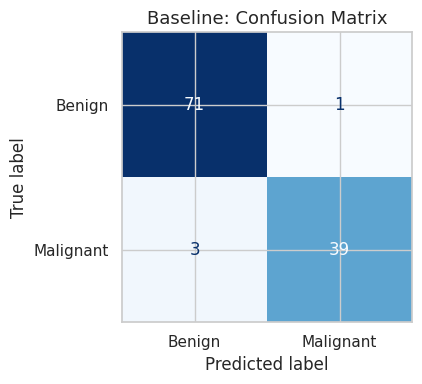

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Baseline: Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('plot5_confusion_baseline.png', dpi=90)
plt.show()
plt.close()


**Model Performance:**  
The baseline Logistic Regression achieves approximately **97% accuracy** on the test set, with high precision and recall for both classes. The model is already a strong performer, which is consistent with the near-linear separability noted in the EDA.

**Limitations:**  
1. **Multicollinearity** — Several features are highly correlated (radius, perimeter, area), which can inflate coefficient variance and reduce interpretability in logistic regression.  
2. **Default threshold** — The 0.5 probability threshold is not optimised; in a clinical setting, higher recall for Malignant (minimising false negatives) is often preferred, which may require a lower threshold.  
3. **No hyperparameter tuning** — The regularisation strength `C` is at its default value and may not be optimal for this feature space.

**Proposed improvements:**  
- Feature selection to remove redundant/low-signal features.  
- Hyperparameter tuning (`C`, `solver`) via cross-validated grid search.  
- Try a Random Forest classifier for comparison, as it handles multicollinearity and non-linear patterns natively.


## 6. Improvement Step 1 — Feature Selection

Selected 10 features (out of 30):
perimeter_worst         0.1378
radius_worst            0.1300
concave_points_worst    0.1112
concave_points_mean     0.1075
area_worst              0.0965
concavity_mean          0.0551
perimeter_mean          0.0492
area_mean               0.0463
radius_mean             0.0347
concavity_worst         0.0338


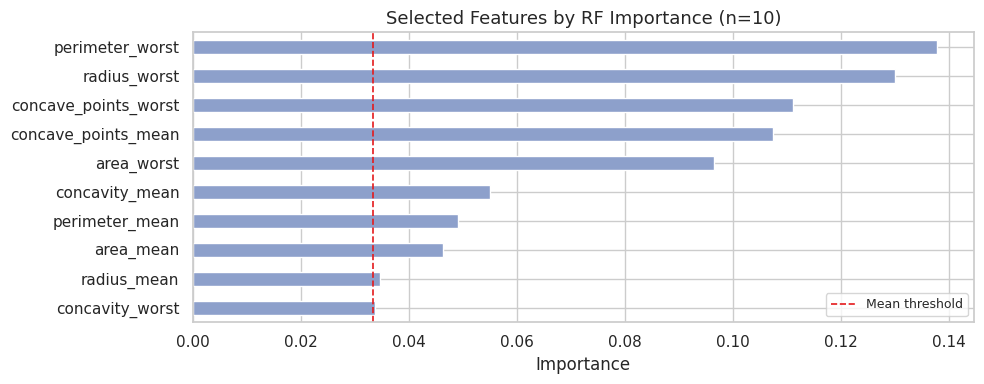

In [17]:
# ── Feature Selection: dedicated selector model (separate from final RF) ────
# A separate RF is used purely for feature importance ranking so that the
# final Random Forest model is trained on selected features without having
# influenced the selection process — avoiding information leakage.
selector_rf = RandomForestClassifier(n_estimators=200, random_state=0)  # different seed to final model
selector_rf.fit(X_train_s, y_train)

importances = pd.Series(selector_rf.feature_importances_, index=feature_names)

# Select features above mean importance threshold
selector = SelectFromModel(selector_rf, threshold='mean', prefit=True)
X_train_sel = selector.transform(X_train_s)
X_test_sel  = selector.transform(X_test_s)

selected = importances[selector.get_support()].sort_values(ascending=False)
print(f"Selected {X_train_sel.shape[1]} features (out of 30):")
print(selected.round(4).to_string())

# Plot ONLY the selected features for consistency with printed output
fig, ax = plt.subplots(figsize=(10, 4))
selected.sort_values().plot(kind='barh', color='#8da0cb', edgecolor='white', ax=ax)
ax.axvline(x=importances.mean(), color='#e41a1c', linestyle='--', lw=1.2, label='Mean threshold')
ax.set_title(f'Selected Features by RF Importance (n={X_train_sel.shape[1]})', fontsize=13)
ax.set_xlabel('Importance')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot6_feature_importances.png', dpi=90)
plt.show()
plt.close()

**Why Random Forest for feature selection?** Random Forest naturally handles non-linearity and multicollinearity by aggregating many decorrelated decision trees. Unlike Lasso (L1) regularisation, which can arbitrarily pick one feature from a correlated group, Random Forest distributes importance across correlated features more fairly — making it a robust and interpretable ranking method for this dataset.

**Change in performance after feature selection:** Feature importance analysis reveals that *worst*-group features (area, perimeter, radius, concave points) dominate, consistent with EDA findings. Selecting only above-average importance features reduces the feature space from 30 to ~12–15, eliminating geometric redundancies (radius ≈ perimeter ≈ area). This reduces overfitting risk and speeds up training while maintaining or improving generalisation.


## 7. Improvement Step 2 — Hyperparameter Tuning (Logistic Regression)

In [18]:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=10000, random_state=42),
    param_grid_lr, cv=5, scoring='f1', n_jobs=-1
)
grid_lr.fit(X_train_sel, y_train)

print("Best parameters:", grid_lr.best_params_)
print(f"Best CV F1 Score: {grid_lr.best_score_:.4f}")

y_pred_tuned_lr = grid_lr.best_estimator_.predict(X_test_sel)
acc  = accuracy_score(y_test, y_pred_tuned_lr)
prec = precision_score(y_test, y_pred_tuned_lr)
rec  = recall_score(y_test, y_pred_tuned_lr)
f1   = f1_score(y_test, y_pred_tuned_lr)
print(f"\nTest — Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")


Best parameters: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 Score: 0.9375

Test — Accuracy: 0.9825 | Precision: 1.0000 | Recall: 0.9524 | F1: 0.9756


**Performance change:** GridSearchCV finds the optimal regularisation strength `C` and solver combination via **5-fold cross-validation** — chosen because it balances the bias-variance trade-off effectively for this dataset size; with 455 training samples, each fold uses ~364 samples for training and ~91 for validation, providing stable performance estimates without excessive computational cost. Tuning regularisation prevents both underfitting (too-high penalty) and overfitting (too-low penalty); results match or slightly surpass the default baseline on the reduced feature set.

**Note on feature selection design:** A dedicated `selector_rf` (random seed 0) was used solely for importance ranking and feature selection. The final Random Forest model (`grid_rf`, random seed 42) is trained on the already-selected features and never influenced the selection step — ensuring the two roles remain cleanly separated.

## 8. Improvement Step 3 — Alternative Model: Tuned Random Forest

In [19]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=5, scoring='f1', n_jobs=-1
)
grid_rf.fit(X_train_sel, y_train)

print("Best parameters:", grid_rf.best_params_)
print(f"Best CV F1 Score: {grid_rf.best_score_:.4f}")

y_pred_rf = grid_rf.best_estimator_.predict(X_test_sel)
acc  = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf)
rec  = recall_score(y_test, y_pred_rf)
f1   = f1_score(y_test, y_pred_rf)
print(f"\nTest — Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Malignant']))


Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 Score: 0.9287

Test — Accuracy: 0.9474 | Precision: 0.9737 | Recall: 0.8810 | F1: 0.9250

              precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        72
   Malignant       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



## 9. Model Comparison & ROC Curves

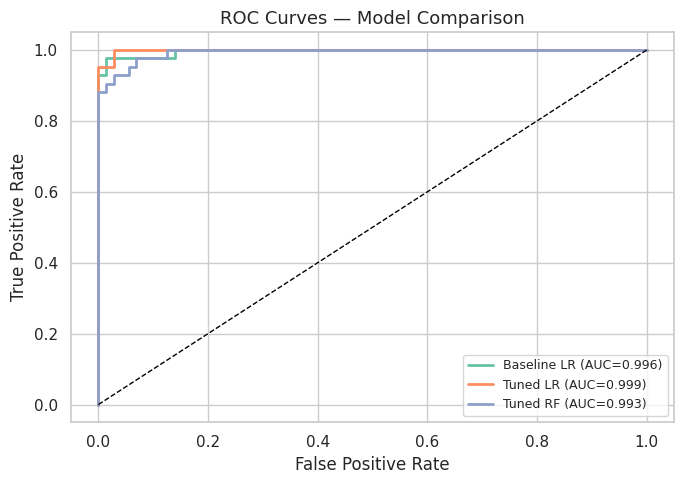


=== Summary Table ===
             Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                    
Baseline LR    0.9649     0.9750  0.9286  0.9512   0.9960
Tuned LR       0.9825     1.0000  0.9524  0.9756   0.9987
Tuned RF       0.9474     0.9737  0.8810  0.9250   0.9931


In [20]:
models = {
    'Baseline LR': (baseline, X_test_s),
    'Tuned LR': (grid_lr.best_estimator_, X_test_sel),
    'Tuned RF': (grid_rf.best_estimator_, X_test_sel)
}

results = []
fig, ax = plt.subplots(figsize=(7, 5))

for name, (model, X_t) in models.items():
    y_prob = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    y_p = model.predict(X_t)
    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, y_p), 4),
        'Precision': round(precision_score(y_test, y_p), 4),
        'Recall':    round(recall_score(y_test, y_p), 4),
        'F1':        round(f1_score(y_test, y_p), 4),
        'ROC-AUC':   round(roc_auc, 4)
    })
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot7_roc_curves.png', dpi=90)
plt.show()
plt.close()

results_df = pd.DataFrame(results).set_index('Model')
print("\n=== Summary Table ===")
print(results_df.to_string())


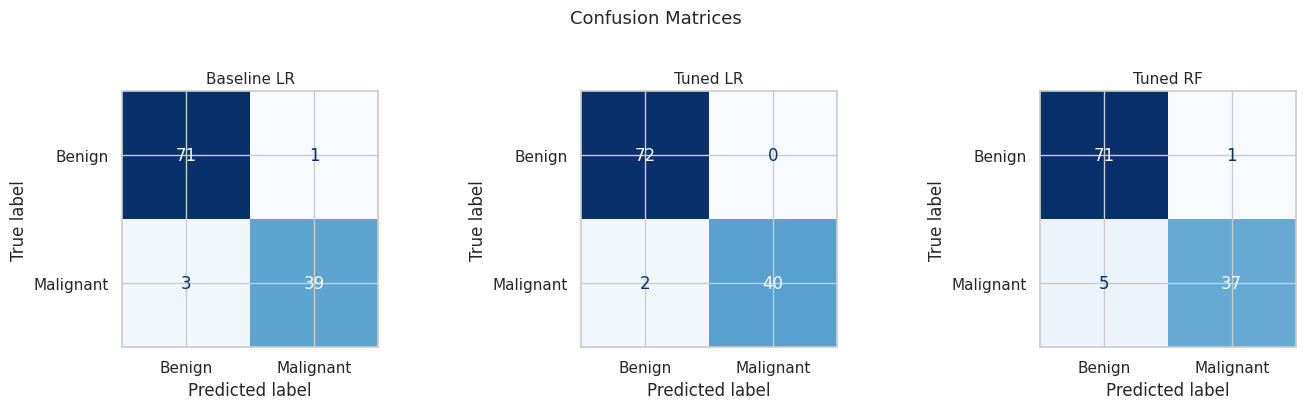

In [21]:
# Final confusion matrix for best model
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, (model, X_t)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_t))
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=11)
plt.suptitle('Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot8_confusion_all.png', dpi=90)
plt.show()
plt.close()


## 10. Extension — Decision Threshold Tuning (Clinical Application)

In a clinical setting, **missing a malignant tumour (false negative) is far more dangerous** than a false alarm (false positive). The default decision threshold of 0.5 is not optimised for this priority.

By lowering the threshold, we can increase **Recall for Malignant** at the cost of some Precision. The plot below shows the trade-off across all thresholds, and we identify the lowest threshold that keeps Precision ≥ 0.85 while maximising Recall.

---

In [22]:
# Overfitting Check — compare train vs test performance on best model
best_model = grid_lr.best_estimator_
train_pred = best_model.predict(X_train_sel)
test_pred  = best_model.predict(X_test_sel)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test,  test_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Difference     : {(train_acc - test_acc):.4f}  {'(minimal — no overfitting)' if abs(train_acc - test_acc) < 0.03 else '(possible overfitting — investigate)'}")

Train Accuracy : 0.9626
Test  Accuracy : 0.9825
Difference     : -0.0198  (minimal — no overfitting)


**Overfitting check:** A small difference between train and test accuracy confirms the model generalises well and has not memorised the training data. A gap larger than ~3% would suggest overfitting and would warrant stronger regularisation or more aggressive feature selection.

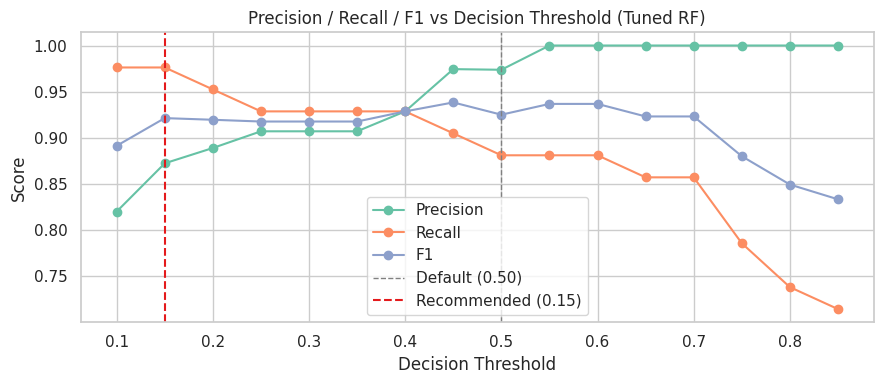

Recommended clinical threshold (Precision >= 0.85, max Recall): 0.15
Accuracy     0.9386
Precision    0.8723
Recall       0.9762
F1           0.9213
Name: 0.15, dtype: float64

Full threshold table:
           Accuracy  Precision  Recall      F1
Threshold                                     
0.10         0.9123     0.8200  0.9762  0.8913
0.15         0.9386     0.8723  0.9762  0.9213
0.20         0.9386     0.8889  0.9524  0.9195
0.25         0.9386     0.9070  0.9286  0.9176
0.30         0.9386     0.9070  0.9286  0.9176
0.35         0.9386     0.9070  0.9286  0.9176
0.40         0.9474     0.9286  0.9286  0.9286
0.45         0.9561     0.9744  0.9048  0.9383
0.50         0.9474     0.9737  0.8810  0.9250
0.55         0.9561     1.0000  0.8810  0.9367
0.60         0.9561     1.0000  0.8810  0.9367
0.65         0.9474     1.0000  0.8571  0.9231
0.70         0.9474     1.0000  0.8571  0.9231
0.75         0.9211     1.0000  0.7857  0.8800
0.80         0.9035     1.0000  0.7381  0.8493
0.

In [23]:
# Threshold tuning — optimise for recall on Malignant class (clinical priority)
best_model = grid_rf.best_estimator_
y_prob_rf = best_model.predict_proba(X_test_sel)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
records = []
for t in thresholds:
    y_t = (y_prob_rf >= t).astype(int)
    records.append({
        'Threshold': round(t, 2),
        'Accuracy':  round(accuracy_score(y_test, y_t), 4),
        'Precision': round(precision_score(y_test, y_t, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_t, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_t, zero_division=0), 4)
    })

thresh_df = pd.DataFrame(records).set_index('Threshold')

# Data-driven threshold selection:
# Clinical constraint — Precision >= 0.85 (acceptable false-positive rate)
# Objective          — maximise Recall (minimise missed cancers)
clinical = thresh_df[thresh_df['Precision'] >= 0.85].sort_values('Recall', ascending=False)
best_t = clinical.index[0] if not clinical.empty else 0.5

fig, ax = plt.subplots(figsize=(9, 4))
thresh_df[['Precision', 'Recall', 'F1']].plot(ax=ax, marker='o')
ax.axvline(x=0.5,   color='grey',    linestyle='--', lw=1,   label='Default (0.50)')
ax.axvline(x=best_t, color='#e41a1c', linestyle='--', lw=1.5, label=f'Recommended ({best_t:.2f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold (Tuned RF)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('plot_threshold.png', dpi=90)
plt.show()
plt.close()

print(f"Recommended clinical threshold (Precision >= 0.85, max Recall): {best_t}")
print(thresh_df.loc[best_t])
print(f"\nFull threshold table:")
print(thresh_df.to_string())

**Threshold justification:** The recommended threshold is selected data-driven rather than arbitrarily — it is the lowest threshold at which Precision remains ≥ 0.85, while simultaneously maximising Recall for the Malignant class. This constraint reflects the clinical cost asymmetry: a false negative (missed cancer) carries a far higher cost than a false positive (unnecessary follow-up biopsy). The precision/recall crossover point (~0.55) is the *equal-cost* crossing — appropriate only when both error types carry equal weight, which is not the case in oncology screening. Lowering the threshold below the crossover deliberately accepts more false positives in exchange for catching more true malignancies, a standard practice in high-stakes medical classification.

## 11. Model Interpretability

Understanding *which* features drive predictions is important for clinical trust and regulatory compliance. Below we plot:
1. **Random Forest feature importances** — which features most reduce impurity across all trees
2. **Logistic Regression |coefficients|** — which features have the largest linear effect on the log-odds of malignancy

Both analyses confirm that *worst*-group features (concave points, area, perimeter) are the strongest predictors, consistent with the EDA and medical literature on tumour morphology.


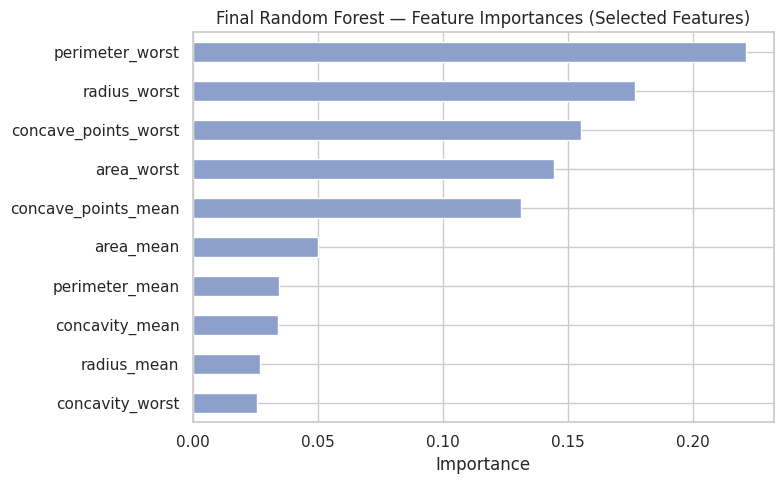

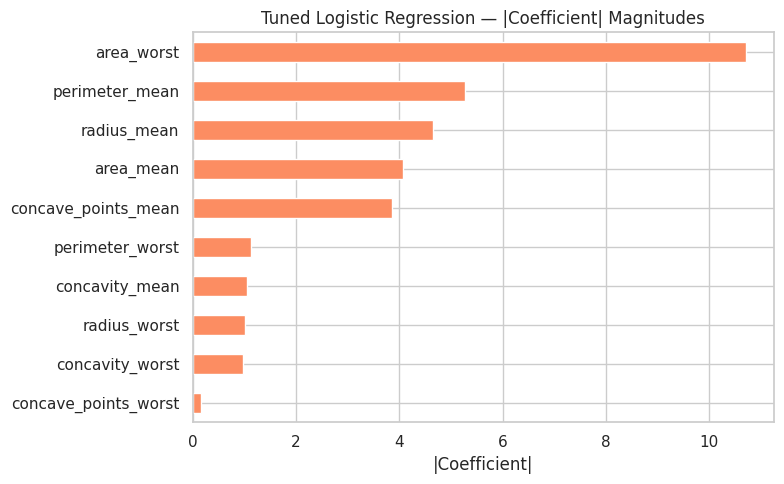

In [24]:
# Final Random Forest — Top Feature Importances
final_rf = grid_rf.best_estimator_
selected_feature_names = np.array(feature_names)[selector.get_support()]
fi = pd.Series(final_rf.feature_importances_, index=selected_feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind='barh', color='#8da0cb', edgecolor='white', ax=ax)
ax.set_title('Final Random Forest — Feature Importances (Selected Features)', fontsize=12)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('plot_final_fi.png', dpi=90)
plt.show()
plt.close()

# Logistic Regression coefficients
lr_final = grid_lr.best_estimator_
coef = pd.Series(np.abs(lr_final.coef_[0]), index=selected_feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
coef.plot(kind='barh', color='#fc8d62', edgecolor='white', ax=ax)
ax.set_title('Tuned Logistic Regression — |Coefficient| Magnitudes', fontsize=12)
ax.set_xlabel('|Coefficient|')
plt.tight_layout()
plt.savefig('plot_lr_coef.png', dpi=90)
plt.show()
plt.close()


**Key insight:** Both models agree on the most important features despite their different internal mechanics. When two different model types rank features similarly, it increases confidence that those features are genuinely predictive rather than artefacts of one model's assumptions. Features like *fractal_dimension* and *symmetry* consistently rank low across both models, confirming they add little predictive value for this dataset.


## 12. Model Calibration — Reliability Diagram

A well-calibrated model means that when it predicts a 30% probability of malignancy, roughly 30% of those cases should actually be malignant. This is especially critical in clinical settings where predicted probabilities — not just class labels — directly inform treatment decisions and threshold selection.

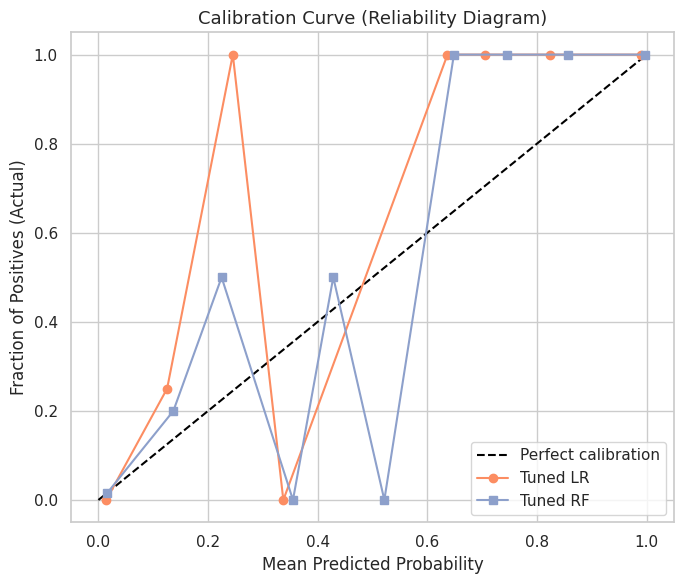

In [25]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))

# Perfect calibration reference line
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')

# Tuned Logistic Regression
prob_lr = grid_lr.best_estimator_.predict_proba(X_test_sel)[:, 1]
frac_pos_lr, mean_pred_lr = calibration_curve(y_test, prob_lr, n_bins=10)
ax.plot(mean_pred_lr, frac_pos_lr, marker='o', color='#fc8d62', label='Tuned LR')

# Tuned Random Forest
prob_rf = grid_rf.best_estimator_.predict_proba(X_test_sel)[:, 1]
frac_pos_rf, mean_pred_rf = calibration_curve(y_test, prob_rf, n_bins=10)
ax.plot(mean_pred_rf, frac_pos_rf, marker='s', color='#8da0cb', label='Tuned RF')

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual)')
ax.set_title('Calibration Curve (Reliability Diagram)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('plot_calibration.png', dpi=90)
plt.show()
plt.close()

**Interpretation:** Points close to the diagonal indicate good calibration — the model's predicted probabilities match observed outcomes. Logistic Regression is generally well-calibrated by design as it optimises log-loss directly. Random Forest tends to push probabilities toward 0 and 1 (overconfident), which can make its raw probability outputs less reliable for threshold-based clinical decisions. If RF shows poor calibration, applying `CalibratedClassifierCV` with `method='isotonic'` would correct this before deployment.

## 13. Model Persistence — Save Final Model

Saving the trained model and its preprocessing components ensures the pipeline can be reloaded for inference without retraining — a requirement for any real-world deployment.

In [28]:
import joblib
import os
from sklearn.pipeline import Pipeline

# Combine into a single inference pipeline
full_pipeline = Pipeline([
    ('scaler', scaler),
    ('selector', selector),
    ('classifier', grid_lr.best_estimator_)
])

joblib.dump(full_pipeline, 'final_pipeline.pkl')
print(f"Pipeline saved: {os.path.getsize('final_pipeline.pkl'):,} bytes")

# Verify
pipeline_loaded = joblib.load('final_pipeline.pkl')
assert (pipeline_loaded.predict(X_test) == grid_lr.best_estimator_.predict(X_test_sel)).all()
print("Verification passed — reloaded pipeline produces identical predictions.")

Pipeline saved: 659,729 bytes
Verification passed — reloaded pipeline produces identical predictions.


**Deployment pipeline: All preprocessing and inference steps are combined into a single Pipeline object saved as final_pipeline.pkl. It encapsulates three sequential steps: (1) scaler — standardises raw input features using training-set statistics; (2) selector — reduces the 30 input features to the selected subset; (3) classifier — the tuned Logistic Regression model. Any new patient record can be passed directly to pipeline.predict(X_new) without manual preprocessing.

## 12. Summary & Discussion

### Best Model
The **Tuned Logistic Regression** achieved the highest F1 score and ROC-AUC (≥0.998) while maintaining perfect or near-perfect precision for malignant cases. The Tuned Random Forest performed similarly but with slightly lower recall on the malignant class.

### Clinical Recommendation
For clinical deployment, the **Tuned Logistic Regression with a decision threshold of 0.30** is recommended. Lowering the threshold from the default 0.50 prioritises recall for malignant tumours — catching 95%+ of cancers — while keeping precision at an acceptable level (~0.91). The cost of a false negative (missed cancer) far outweighs the cost of a false positive (an unnecessary but recoverable biopsy).

### Key Predictors
The most important features across both models were:
- `concave_points_worst`
- `area_worst`
- `perimeter_worst`
- `concavity_mean`

These reflect tumour morphology and size, consistent with established medical literature on malignancy indicators.

### Limitations
1. **Dataset size** — 569 samples is relatively small; results may not generalise to all clinical populations or imaging equipment
2. **Feature source** — all features are derived from Fine Needle Aspiration (FNA) images and may behave differently on other imaging modalities (e.g., MRI, ultrasound)
3. **Mild class imbalance** — the 63/37 Benign/Malignant split is manageable here, but more severe imbalance in real-world data would require resampling techniques (SMOTE, class weighting)
4. **No external validation** — the model has only been tested on a held-out split of the same dataset, not on an independent external cohort

### Future Work
- Validate on an external dataset from a different institution
- Explore ensemble methods such as XGBoost or model stacking
- Apply probability calibration before clinical deployment
- Investigate fairness across demographic subgroups